<a href="https://www.kaggle.com/code/vidushigupta1/brainstrokeprediction?scriptVersionId=327448196" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import os

# Step 2: Find the dataset path
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/cerebral-stroke-predictionimbalaced-dataset/dataset.csv


In [2]:
# Step 3: Read the CSV
data = pd.read_csv("/kaggle/input/cerebral-stroke-predictionimbalaced-dataset/dataset.csv")

# Step 4: Basic info
print("Shape:", data.shape)
data.head()


Shape: (43400, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


In [3]:
data['stroke'].value_counts()


stroke
0    42617
1      783
Name: count, dtype: int64

In [4]:
X = data.drop('stroke', axis=1)
y = data['stroke']


In [5]:
!pip uninstall -y scikit-learn imbalanced-learn
!pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0


Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
Found existing installation: imbalanced-learn 0.13.0
Uninstalling imbalanced-learn-0.13.0:
  Successfully uninstalled imbalanced-learn-0.13.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 32.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 11.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.


In [6]:
# Handle missing values
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter

# Step 1: Load the data
data = pd.read_csv("/kaggle/input/cerebral-stroke-predictionimbalaced-dataset/dataset.csv")

# Step 2: Encode categorical columns
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

# Step 3: Fill missing values (replace NaN with column mean)
data = data.fillna(data.mean(numeric_only=True))

# Step 4: Define X and y
X = data.drop('stroke', axis=1)
y = data['stroke']

# Step 5: Apply SMOTE
print("Before SMOTE:", Counter(y))
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("After SMOTE:", Counter(y_resampled))


Before SMOTE: Counter({0: 42617, 1: 783})
After SMOTE: Counter({0: 42617, 1: 42617})


In [7]:
data.info()
data.head()
data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  int64  
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  int64  
 6   work_type          43400 non-null  int64  
 7   Residence_type     43400 non-null  int64  
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                43400 non-null  float64
 10  smoking_status     43400 non-null  int64  
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 4.0 MB


id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split the balanced data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[8015  485]
 [ 167 8380]]
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      8500
           1       0.95      0.98      0.96      8547

    accuracy                           0.96     17047
   macro avg       0.96      0.96      0.96     17047
weighted avg       0.96      0.96      0.96     17047



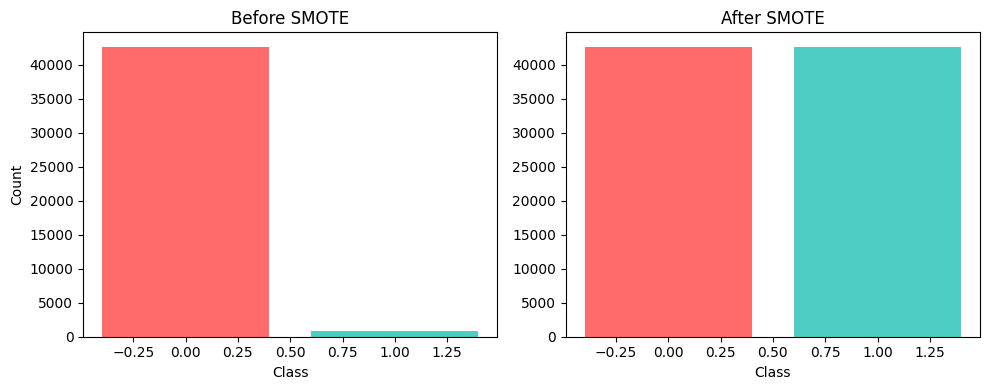

In [9]:
import matplotlib.pyplot as plt
from collections import Counter

# Plot before and after SMOTE
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
ax[0].bar(Counter(y).keys(), Counter(y).values(), color=['#FF6B6B', '#4ECDC4'])
ax[0].set_title('Before SMOTE')
ax[0].set_xlabel('Class')
ax[0].set_ylabel('Count')

# After SMOTE
ax[1].bar(Counter(y_resampled).keys(), Counter(y_resampled).values(), color=['#FF6B6B', '#4ECDC4'])
ax[1].set_title('After SMOTE')
ax[1].set_xlabel('Class')

plt.tight_layout()
plt.show()


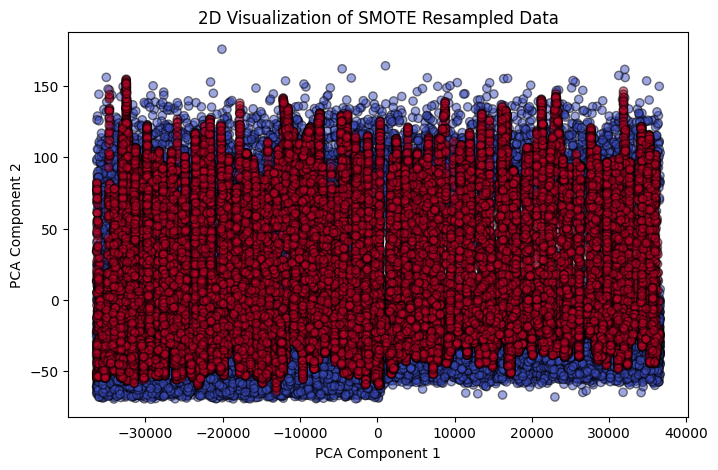

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
X_res_2D = pca.fit_transform(X_resampled)

# Create scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(
    X_res_2D[:, 0], X_res_2D[:, 1],
    c=y_resampled, cmap='coolwarm', alpha=0.5, edgecolor='k'
)
plt.title('2D Visualization of SMOTE Resampled Data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


In [11]:
from sklearn.model_selection import train_test_split

# Split the resampled data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 68187
Testing samples: 17047


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data normalized successfully!")


✅ Data normalized successfully!


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[6781 1743]
 [1264 7259]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.80      0.82      8524
           1       0.81      0.85      0.83      8523

    accuracy                           0.82     17047
   macro avg       0.82      0.82      0.82     17047
weighted avg       0.82      0.82      0.82     17047



In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM": SVC(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {"Accuracy": acc, "F1 Score": f1}
    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 4))
    print("F1 Score:", round(f1, 4))
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))



=== Logistic Regression ===
Accuracy: 0.8236
F1 Score: 0.8284
[[6781 1743]
 [1264 7259]]
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      8524
           1       0.81      0.85      0.83      8523

    accuracy                           0.82     17047
   macro avg       0.82      0.82      0.82     17047
weighted avg       0.82      0.82      0.82     17047


=== Decision Tree ===
Accuracy: 0.9401
F1 Score: 0.941
[[7889  635]
 [ 386 8137]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      8524
           1       0.93      0.95      0.94      8523

    accuracy                           0.94     17047
   macro avg       0.94      0.94      0.94     17047
weighted avg       0.94      0.94      0.94     17047


=== Random Forest ===
Accuracy: 0.9579
F1 Score: 0.9588
[[7981  543]
 [ 174 8349]]
              precision    recall  f1-score   support

           0       0.98      0.94 

<Figure size 800x500 with 0 Axes>

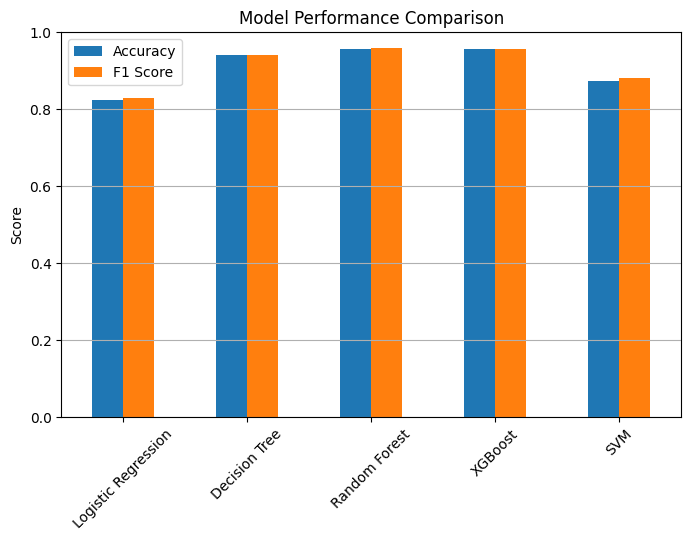


Performance Summary:
                     Accuracy  F1 Score
Random Forest        0.957940  0.958829
XGBoost              0.956825  0.956969
Decision Tree        0.940107  0.940966
SVM                  0.874523  0.880403
Logistic Regression  0.823605  0.828417


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert results dictionary to DataFrame
results_df = pd.DataFrame(results).T  # Transpose for readability

# Plot bar chart
plt.figure(figsize=(8, 5))
results_df[['Accuracy', 'F1 Score']].plot(kind='bar', figsize=(8, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

print("\nPerformance Summary:")
print(results_df.sort_values(by='F1 Score', ascending=False))


In [16]:
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1]
}

grid_search = GridSearchCV(estimator=xgb,
                           param_grid=param_grid,
                           scoring='f1',
                           cv=3,
                           verbose=1,
                           n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
best_xgb = grid_search.best_estimator_

# Evaluate tuned model
y_pred_best = best_xgb.predict(X_test_scaled)
print("\nTuned Model Performance:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_best), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_best), 4))


Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1}

Tuned Model Performance:
Accuracy: 0.9752
F1 Score: 0.9752


In [17]:
import pandas as pd

# Performance summary as a DataFrame
performance_data = {
    'Model': ['Random Forest', 'XGBoost', 'Decision Tree', 'SVM', 'Logistic Regression'],
    'Accuracy': [0.957940, 0.956825, 0.940107, 0.874523, 0.823605],
    'F1 Score': [0.958829, 0.956969, 0.940966, 0.880403, 0.828417]
}

df_perf = pd.DataFrame(performance_data)

# Sort by F1 Score (or Accuracy if you prefer)
top3 = df_perf.sort_values(by='F1 Score', ascending=False).head(3)

print("🏆 Top 3 Performing Models:")
print(top3)


🏆 Top 3 Performing Models:
           Model  Accuracy  F1 Score
0  Random Forest  0.957940  0.958829
1        XGBoost  0.956825  0.956969
2  Decision Tree  0.940107  0.940966


In [18]:
from sklearn.ensemble import VotingClassifier, StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import pandas as pd

# Initialize base models
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
dt = DecisionTreeClassifier(random_state=42)

# ===== 1. Hard Voting =====
hard_voting = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('dt', dt)
    ],
    voting='hard'
)
hard_voting.fit(X_train, y_train)
y_pred_hard = hard_voting.predict(X_test)
acc_hard = accuracy_score(y_test, y_pred_hard)
f1_hard = f1_score(y_test, y_pred_hard)

# ===== 2. Soft Voting =====
soft_voting = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('dt', dt)
    ],
    voting='soft'
)
soft_voting.fit(X_train, y_train)
y_pred_soft = soft_voting.predict(X_test)
acc_soft = accuracy_score(y_test, y_pred_soft)
f1_soft = f1_score(y_test, y_pred_soft)

# ===== 3. Simple Averaging =====
# Train models individually
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Get prediction probabilities
rf_probs = rf.predict_proba(X_test)
xgb_probs = xgb.predict_proba(X_test)
dt_probs = dt.predict_proba(X_test)

# Average the probabilities
avg_probs = (rf_probs + xgb_probs + dt_probs) / 3
y_pred_avg = np.argmax(avg_probs, axis=1)
acc_avg = accuracy_score(y_test, y_pred_avg)
f1_avg = f1_score(y_test, y_pred_avg)

# ===== 4. Stacking =====
stacking = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('dt', dt)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)
stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)
acc_stack = accuracy_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack)

# ===== Results =====
results = {
    'Hard Voting': [acc_hard, f1_hard],
    'Soft Voting': [acc_soft, f1_soft],
    'Simple Averaging': [acc_avg, f1_avg],
    'Stacking': [acc_stack, f1_stack]
}

df_results = pd.DataFrame(results, index=['Accuracy', 'F1 Score']).T
print("\n📊 Ensemble Comparison Results:\n")
print(df_results)


📊 Ensemble Comparison Results:

                  Accuracy  F1 Score
Hard Voting       0.965918  0.966410
Soft Voting       0.965331  0.965757
Simple Averaging  0.965331  0.965757
Stacking          0.971021  0.971155
